<a href="https://colab.research.google.com/github/JahnaviRudresh/Cognifyz_Machine_Learning-_Internship/blob/main/Cognifyz_Task_3_cuisine_classsification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Cognifyz Technologies
Machine Learning Internship

Task 3: Cuisine Classification

Objective:
Develop a machine learning model to classify restaurants based on their cuisines.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Dataset  (1).csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [ ]:
df = df.dropna(subset=['Cuisines'])

In [ ]:
df['Cuisines'].value_counts().head(10)

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Chinese,354
Fast Food,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170


In [ ]:
df['Primary Cuisine'] = df['Cuisines'].str.split(',').str[0].str.strip()

In [ ]:
df[['Cuisines', 'Primary Cuisine']].head(10)

,Cuisines,Primary Cuisine
0,"French, Japanese, Desserts",French
1,Japanese,Japanese
2,"Seafood, Asian, Filipino, Indian",Seafood
3,"Japanese, Sushi",Japanese
4,"Japanese, Korean",Japanese
5,Chinese,Chinese
6,"Asian, European",Asian
7,"Seafood, Filipino, Asian, European",Seafood
8,"European, Asian, Indian",European
9,Filipino,Filipino


In [ ]:
df['Primary Cuisine'].nunique()

119

In [ ]:
df['Primary Cuisine'].value_counts().tail(10)

,count
Primary Cuisine,
Malwani,1
Cuisine Varies,1
Ramen,1
Scottish,1
Kiwi,1
Indonesian,1
Sri Lankan,1
Argentine,1
Patisserie,1


In [ ]:
cuisine_counts = df['Primary Cuisine'].value_counts()

(cuisine_counts >= 20).sum()

np.int64(33)

In [ ]:
valid_cuisines = cuisine_counts[cuisine_counts >= 20].index

df = df[df['Primary Cuisine'].isin(valid_cuisines)]


In [ ]:
df.shape

(9097, 22)

In [ ]:
X = df[['Average Cost for two',
        'Price range',
        'Aggregate rating',
        'Votes',
        'Has Table booking',
        'Has Online delivery']]

y = df['Primary Cuisine']

In [ ]:
X.head()

,Average Cost for two,Price range,Aggregate rating,Votes,Has Table booking,Has Online delivery
1,1200,3,4.5,591,Yes,No
2,4000,4,4.4,270,Yes,No
3,1500,4,4.9,365,No,No
4,1500,4,4.8,229,Yes,No
5,1000,3,4.4,336,No,No


In [ ]:
y.head()

,Primary Cuisine
1,Japanese
2,Seafood
3,Japanese
4,Japanese
5,Chinese


In [ ]:
y.value_counts().head(10)

,count
Primary Cuisine,
North Indian,2992
Chinese,855
Fast Food,672
Bakery,621
Cafe,617
American,278
South Indian,262
Mithai,246
Street Food,236


In [ ]:
X['Has Table booking'] = X['Has Table booking'].map({'Yes': 1, 'No': 0})
X['Has Online delivery'] = X['Has Online delivery'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_1278/3498386693.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Has Table booking'] = X['Has Table booking'].map({'Yes': 1, 'No': 0})
/tmp/ipykernel_1278/3498386693.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Has Online delivery'] = X['Has Online delivery'].map({'Yes': 1, 'No': 0})


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.32967032967032966
Accuracy (%): 32.967032967032964


In [ ]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print("Precision:", precision)
print("Precision (%):", precision * 100)

print("Recall:", recall)
print("Recall (%):", recall * 100)

Precision: 0.11322510529268037
Precision (%): 11.322510529268037
Recall: 0.32967032967032966
Recall (%): 32.967032967032964


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

               precision    recall  f1-score   support

     American       0.11      0.02      0.03        56
        Asian       0.00      0.00      0.00        15
       Bakery       0.00      0.00      0.00       124
    Beverages       0.00      0.00      0.00        16
      Biryani       0.00      0.00      0.00        22
    Brazilian       0.00      0.00      0.00         4
    Breakfast       0.12      0.20      0.15         5
       Burger       0.00      0.00      0.00        23
         Cafe       0.00      0.00      0.00       124
      Chinese       0.00      0.00      0.00       171
  Continental       0.00      0.00      0.00        47
     Desserts       0.00      0.00      0.00        30
     European       0.00      0.00      0.00        12
    Fast Food       0.00      0.00      0.00       135
  Finger Food       0.00      0.00      0.00        16
 Healthy Food       0.00      0.00      0.00        11
    Ice Cream       0.00      0.00      0.00        36
       In

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Dataset  (1).csv")

In [ ]:
df = df.dropna(subset=['Cuisines'])

df['Primary Cuisine'] = df['Cuisines'].str.split(',').str[0].str.strip()

In [ ]:
cuisine_counts = df['Primary Cuisine'].value_counts()

valid_cuisines = cuisine_counts[cuisine_counts >= 20].index

df = df[df['Primary Cuisine'].isin(valid_cuisines)]

In [ ]:
X = df[['Average Cost for two',
        'Price range',
        'Aggregate rating',
        'Votes',
        'Has Table booking',
        'Has Online delivery']]

y = df['Primary Cuisine']

In [ ]:
X['Has Table booking'] = X['Has Table booking'].map({'Yes': 1, 'No': 0})
X['Has Online delivery'] = X['Has Online delivery'].map({'Yes': 1, 'No': 0})

/tmp/ipykernel_2352/3498386693.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Has Table booking'] = X['Has Table booking'].map({'Yes': 1, 'No': 0})
/tmp/ipykernel_2352/3498386693.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Has Online delivery'] = X['Has Online delivery'].map({'Yes': 1, 'No': 0})


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")

Accuracy : 32.97%
Precision: 11.32%
Recall   : 32.97%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

               precision    recall  f1-score   support

     American       0.11      0.02      0.03        56
        Asian       0.00      0.00      0.00        15
       Bakery       0.00      0.00      0.00       124
    Beverages       0.00      0.00      0.00        16
      Biryani       0.00      0.00      0.00        22
    Brazilian       0.00      0.00      0.00         4
    Breakfast       0.12      0.20      0.15         5
       Burger       0.00      0.00      0.00        23
         Cafe       0.00      0.00      0.00       124
      Chinese       0.00      0.00      0.00       171
  Continental       0.00      0.00      0.00        47
     Desserts       0.00      0.00      0.00        30
     European       0.00      0.00      0.00        12
    Fast Food       0.00      0.00      0.00       135
  Finger Food       0.00      0.00      0.00        16
 Healthy Food       0.00      0.00      0.00        11
    Ice Cream       0.00      0.00      0.00        36
       In

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average='weighted', zero_division=0)

print(f"Random Forest Accuracy : {rf_accuracy:.2%}")
print(f"Random Forest Precision: {rf_precision:.2%}")
print(f"Random Forest Recall   : {rf_recall:.2%}")

Random Forest Accuracy : 22.64%
Random Forest Precision: 25.29%
Random Forest Recall   : 22.64%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred, zero_division=0))

               precision    recall  f1-score   support

     American       0.36      0.30      0.33        56
        Asian       0.15      0.13      0.14        15
       Bakery       0.15      0.12      0.14       124
    Beverages       0.09      0.31      0.14        16
      Biryani       0.05      0.14      0.07        22
    Brazilian       1.00      0.75      0.86         4
    Breakfast       0.00      0.00      0.00         5
       Burger       0.03      0.04      0.04        23
         Cafe       0.24      0.27      0.25       124
      Chinese       0.14      0.12      0.13       171
  Continental       0.04      0.02      0.03        47
     Desserts       0.00      0.00      0.00        30
     European       0.00      0.00      0.00        12
    Fast Food       0.13      0.08      0.10       135
  Finger Food       0.22      0.25      0.24        16
 Healthy Food       0.00      0.00      0.00        11
    Ice Cream       0.12      0.08      0.10        36
       In

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy],
    'Precision': [precision, rf_precision],
    'Recall': [recall, rf_recall]
})

comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.329670,0.113225,0.329670
1,Random Forest,0.226374,0.252941,0.226374


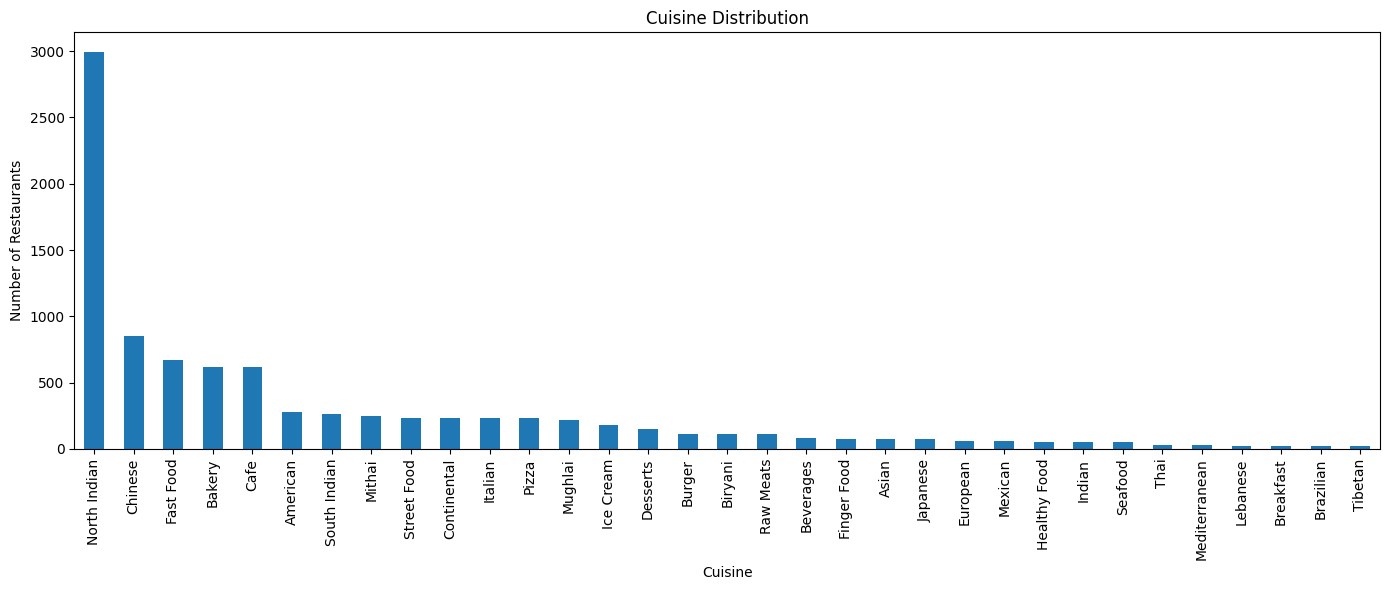

In [ ]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar', figsize=(14, 6))

plt.title("Cuisine Distribution")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)

print(classification_report(y_test, balanced_pred, zero_division=0))

               precision    recall  f1-score   support

     American       0.00      0.00      0.00        56
        Asian       0.01      0.13      0.02        15
       Bakery       0.00      0.00      0.00       124
    Beverages       0.00      0.00      0.00        16
      Biryani       0.00      0.00      0.00        22
    Brazilian       0.00      0.00      0.00         4
    Breakfast       0.09      0.80      0.16         5
       Burger       0.00      0.00      0.00        23
         Cafe       0.00      0.00      0.00       124
      Chinese       0.00      0.00      0.00       171
  Continental       0.00      0.00      0.00        47
     Desserts       0.00      0.00      0.00        30
     European       0.01      0.75      0.02        12
    Fast Food       0.00      0.00      0.00       135
  Finger Food       0.00      0.00      0.00        16
 Healthy Food       0.00      0.00      0.00        11
    Ice Cream       0.00      0.00      0.00        36
       In

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

scaled_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight='balanced')
)

scaled_model.fit(X_train, y_train)
scaled_pred = scaled_model.predict(X_test)

print(classification_report(y_test, scaled_pred, zero_division=0))

               precision    recall  f1-score   support

     American       0.00      0.00      0.00        56
        Asian       0.00      0.00      0.00        15
       Bakery       0.00      0.00      0.00       124
    Beverages       0.02      0.19      0.04        16
      Biryani       0.00      0.00      0.00        22
    Brazilian       0.03      0.50      0.06         4
    Breakfast       0.01      0.20      0.02         5
       Burger       0.14      0.13      0.13        23
         Cafe       0.13      0.09      0.11       124
      Chinese       0.17      0.01      0.02       171
  Continental       0.21      0.06      0.10        47
     Desserts       0.00      0.00      0.00        30
     European       0.17      0.25      0.20        12
    Fast Food       0.00      0.00      0.00       135
  Finger Food       0.12      0.56      0.19        16
 Healthy Food       0.03      0.36      0.05        11
    Ice Cream       0.09      0.39      0.15        36
       In

In [ ]:
final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Balanced Logistic Regression'],
    'Accuracy': [accuracy, rf_accuracy, accuracy_score(y_test, balanced_pred)],
    'Precision': [precision, rf_precision, precision_score(y_test, balanced_pred, average='weighted', zero_division=0)],
    'Recall': [recall, rf_recall, recall_score(y_test, balanced_pred, average='weighted', zero_division=0)]
})

final_comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.329670,0.113225,0.329670
1,Random Forest,0.226374,0.252941,0.226374
2,Balanced Logistic Regression,0.010440,0.000867,0.010440


In [ ]:
final_model = model
final_pred = final_model.predict(X_test)

print(final_pred[:10])

['North Indian' 'North Indian' 'North Indian' 'North Indian' 'American'
 'North Indian' 'North Indian' 'North Indian' 'North Indian'
 'North Indian']


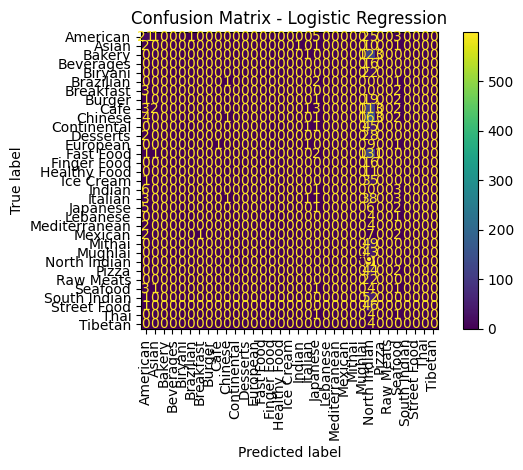

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    xticks_rotation='vertical'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [ ]:
print("FINAL MODEL: Logistic Regression")
print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")

FINAL MODEL: Logistic Regression
Accuracy : 32.97%
Precision: 11.32%
Recall   : 32.97%


In [ ]:
### Performance Analysis and Challenges

The model performs better on some cuisine classes than others. The dataset has a significant class imbalance, with some cuisines having many more restaurants than others. This causes the model to favor majority classes such as North Indian.

The confusion matrix shows that minority cuisines are harder to classify correctly. Therefore, accuracy alone does not fully represent the model's performance.

The main challenges are class imbalance, multiple cuisine categories, and limited samples for some cuisines. Better results could be achieved using more balanced data, additional relevant features, and improved classification techniques.

In [ ]:
performance = pd.crosstab(y_test, final_pred)

correct = pd.Series(0, index=performance.index)

for cuisine in performance.index:
    if cuisine in performance.columns:
        correct[cuisine] = performance.loc[cuisine, cuisine]

correct.sort_values(ascending=False).head(10)

,0
Primary Cuisine,
North Indian,599
American,21
Chinese,1
Italian,1
Seafood,1
Japanese,1
Asian,0
Beverages,0
Bakery,0


In [ ]:
from sklearn.metrics import recall_score

cuisine_recall = pd.DataFrame({
    'Cuisine': sorted(y_test.unique()),
    'Recall': [
        recall_score(y_test, final_pred, labels=[c], average=None, zero_division=0)[0]
        for c in sorted(y_test.unique())
    ]
})

cuisine_recall.sort_values('Recall', ascending=False).head(10)

,Cuisine,Recall
25,North Indian,1.000000
0,American,0.375000
28,Seafood,0.100000
19,Japanese,0.071429
18,Italian,0.021277
9,Chinese,0.005848
1,Asian,0.000000
3,Beverages,0.000000
2,Bakery,0.000000
8,Cafe,0.000000


In [ ]:
### Cuisine-wise Performance Analysis

The model performs differently across cuisine categories. North Indian achieved the highest recall of 100%, while American achieved 37.5%. Seafood, Japanese, Italian, and Chinese had much lower recall, and several cuisines had 0% recall.

This indicates that the model is strongly influenced by class imbalance. Cuisines with more training examples are easier for the model to identify, while cuisines with fewer examples are difficult to classify.

The main challenges are class imbalance, many cuisine categories, and limited samples for minority cuisines. This bias can be reduced by collecting more data for minority classes, using balanced training techniques, and adding more informative features.

In [ ]:
print("TASK 3 - FINAL RESULTS")
print("Model: Logistic Regression")
print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")

TASK 3 - FINAL RESULTS
Model: Logistic Regression
Accuracy : 32.97%
Precision: 11.32%
Recall   : 32.97%
